<a href="https://colab.research.google.com/github/LaliChicken/Altruism_ML_Analysis_Interactive_3D/blob/main/Altruism_ML_Analysis_Interactive_3D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Altruism & Reciprocation Project
This notebook analyzes the class altruism data. We convert the qualitative text columns (Relationship and Action type) into numeric scores:
- Closeness: How close the relationship is (Stranger = 1, Acquaintance/Coworker = 2, Friend = 3, Close Friend = 4, Family/Partner = 5).
- Action Strength: The cost/effort of the action (Verbal = 1, Physical/Other = 2, Service = 3, Gifting = 4).

Then we fit a basic Logistic Regression classifier to predict if an action will be reciprocated, plotting the trials on a 2D scatter plot with a decision boundary, and finally an interactive 3D model.

In [ ]:
!pip install -q transformers
import pandas as pd
import numpy as np
from transformers import pipeline
from tqdm import tqdm
import plotly.graph_objects as go
from sklearn.linear_model import LogisticRegression

df = pd.read_csv('Honors.PUT DATA HERE.Winter2026.Altruism - CLASS DATA.csv')
print(f"Data loaded! Total rows: {len(df)}")

Data loaded! Total rows: 146


In [ ]:
!pip install -q transformers accelerate bitsandbytes tqdm plotly scikit-learn

import pandas as pd
import numpy as np
import torch
import re
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline, BitsAndBytesConfig
from tqdm import tqdm
import plotly.graph_objects as go
from sklearn.neural_network import MLPClassifier
from google.colab import userdata

try:
    hf_token = userdata.get('HF_TOKEN')
except:
    print("ERROR: Please set your HF_TOKEN in Colab secrets!")
    hf_token = None

print("Loading Llama-3 8B in 4-bit precision... (This will take a couple of minutes to download)")
model_id = "meta-llama/Meta-Llama-3-8B-Instruct"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)

tokenizer = AutoTokenizer.from_pretrained(model_id, token=hf_token)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto",
    quantization_config=quantization_config,
    token=hf_token
)

pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=10,
    temperature=0.1,
    do_sample=True,
    pad_token_id=tokenizer.eos_token_id
)

def get_llm_action_score(description):
    if pd.isna(description) or str(description).strip() == "":
        return 1.0

    messages = [
        {"role": "system", "content": "You are an evolutionary psychology researcher. Rate the following altruistic act on a continuous scale from 1.0 to 10.0 based on the total 'cost' to the giver. Consider financial cost, physical effort, time expended, and social risk. 1.0 = practically zero effort. 10.0 = massive sacrifice. Return ONLY a single decimal number. No text."},
        {"role": "user", "content": f"Act: '{description}'"}
    ]

    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    try:
        output = pipe(prompt)[0]['generated_text']
        response = output.split("<|start_header_id|>assistant<|end_header_id|>")[-1].strip()

        match = re.search(r'\d+\.\d+|\d+', response)
        if match:
            score = float(match.group())
            return max(1.0, min(10.0, score))
        else:
            return 1.0
    except Exception as e:
        return 1.0

df = pd.read_csv('Honors.PUT DATA HERE.Winter2026.Altruism - CLASS DATA.csv')
print(f"Dataset loaded! Scoring {len(df)} rows...")

llm_scores = []
for index, row in tqdm(df.iterrows(), total=df.shape[0]):
    llm_scores.append(get_llm_action_score(row['notes']))

df['LLM_Action_Score'] = llm_scores

closeness_map = {'7 - Stranger': 1, '5 - Casual Acquaintance': 2, '6 - Coworker': 2, '8 - Other': 2, '4 - Friend': 3, '3 - Close Friend': 4, '2 - Family Member': 5, '1 - Spouse / Boyfriend / Girlfriend': 5}
reciprocated_map = {'1 - Yes': 1, '2 - No': 0}

df['Closeness'] = df['Subject Type'].map(closeness_map)
df['Reciprocated_Target'] = df['Was it reciprocated?'].map(reciprocated_map)

clean_df = df.dropna(subset=['Closeness', 'LLM_Action_Score', 'Reciprocated_Target']).copy()

print(f"Rows remaining after cleaning: {len(clean_df)}")
if len(clean_df) < 5:
    print("ERROR: Not enough data to plot! Check your column names and mappings.")
    display(df[['Subject Type', 'Was it reciprocated?']].head())
else:
    X = clean_df[['Closeness', 'LLM_Action_Score']].values
    y = clean_df['Reciprocated_Target'].values

    mlp = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=2000, random_state=42)
    mlp.fit(X, y)

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx_3d, yy_3d = np.meshgrid(np.linspace(x_min, x_max, 50), np.linspace(y_min, y_max, 50))
    Z_3d = mlp.predict_proba(np.c_[xx_3d.ravel(), yy_3d.ravel()])[:, 1].reshape(xx_3d.shape)

    np.random.seed(42)
    jitter_x = X[:, 0] + np.random.uniform(-0.15, 0.15, size=len(X))
    jitter_y = X[:, 1] + np.random.uniform(-0.15, 0.15, size=len(X))

    fig = go.Figure()
    fig.add_trace(go.Surface(x=xx_3d, y=yy_3d, z=Z_3d, colorscale='viridis', opacity=0.7, name='LLM Surface', showscale=False))
    fig.add_trace(go.Scatter3d(x=jitter_x[y == 1], y=jitter_y[y == 1], z=y[y == 1], mode='markers', marker=dict(size=6, color='blue', line=dict(width=1, color='black')), name='Reciprocated'))
    fig.add_trace(go.Scatter3d(x=jitter_x[y == 0], y=jitter_y[y == 0], z=y[y == 0], mode='markers', marker=dict(size=6, color='red', line=dict(width=1, color='black')), name='Not Reciprocated'))

    fig.update_layout(
        title='Llama-3 Scored Altruism Model (Neural Network)',
        scene=dict(xaxis_title='Closeness Score', yaxis_title='LLM Action Cost (1.0-10.0)', zaxis_title='Reciprocation Probability'),
        width=900, height=700, margin=dict(l=0, r=0, b=0, t=50)
    )
    fig.show(renderer='colab')

Loading Llama-3 8B in 4-bit precision... (This will take a couple of minutes to download)


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Dataset loaded! Scoring 146 rows...



  0%|          | 0/146 [00:00<?, ?it/s]Both `max_new_tokens` (=10) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)

  1%|          | 1/146 [00:00<00:38,  3.81it/s]Both `max_new_tokens` (=10) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)

  1%|▏         | 2/146 [00:00<00:38,  3.77it/s]Both `max_new_tokens` (=10) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)

  2%|▏         | 3/146 [00:00<00:37,  3.77it/s]Both `max_new_tokens` (=10) and `max_length`(=4096) seem to have b

Rows remaining after cleaning: 142


Found 142 scored rows in memory. Plotting results...


,Subject Type,notes,LLM_Action_Score,Reciprocated_Target
0,5 - Casual Acquaintance,"Had convo in class for the first time, next cl...",6.5,1.0
1,7 - Stranger,I comlimented a workers hair and he later comp...,6.5,1.0
2,4 - Friend,Covered him for a coffee and he bought me boba...,6.5,1.0
3,2 - Family Member,"Drove my mom to Santa Cruz, she bought me food...",6.5,1.0
4,5 - Casual Acquaintance,Helped someone answer a question in class and ...,6.2,1.0


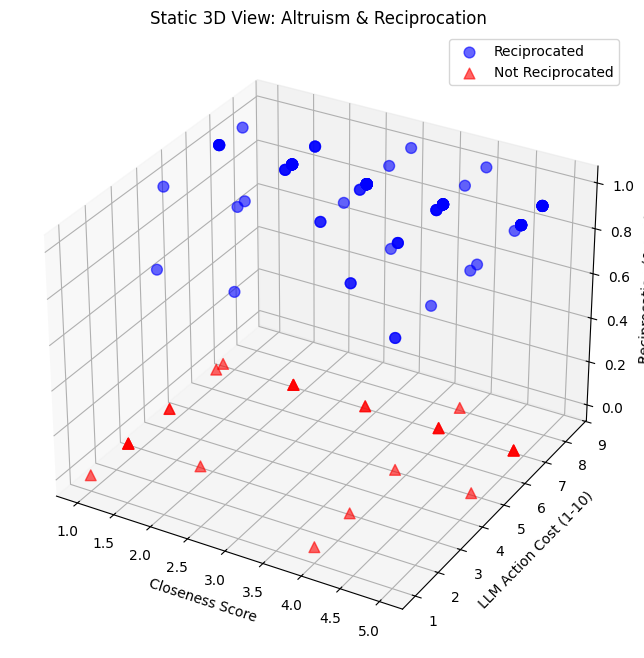

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

if 'clean_df' in locals() and len(clean_df) > 0:
    print(f"Found {len(clean_df)} scored rows in memory. Plotting results...")
    display(clean_df[['Subject Type', 'notes', 'LLM_Action_Score', 'Reciprocated_Target']].head())

    X = clean_df[['Closeness', 'LLM_Action_Score']].values
    y = clean_df['Reciprocated_Target'].values

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(X[y == 1, 0], X[y == 1, 1], y[y == 1], c='blue', marker='o', s=60, label='Reciprocated', alpha=0.6)

    ax.scatter(X[y == 0, 0], X[y == 0, 1], y[y == 0], c='red', marker='^', s=60, label='Not Reciprocated', alpha=0.6)
    ax.set_xlabel('Closeness Score')
    ax.set_ylabel('LLM Action Cost (1-10)')
    ax.set_zlabel('Reciprocation (0 or 1)')
    ax.set_title('Static 3D View: Altruism & Reciprocation')
    ax.legend()

    plt.show()
else:
    print("ERROR: Could not find 'clean_df' in memory. Please ensure the previous cell ran completely.")

In [ ]:
import plotly.graph_objects as go
import numpy as np

if 'mlp' in locals() and 'X' in locals():
    print("Found model and data in memory. Generating interactive plot...")

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx_3d, yy_3d = np.meshgrid(np.linspace(x_min, x_max, 50), np.linspace(y_min, y_max, 50))

    Z_3d = mlp.predict_proba(np.c_[xx_3d.ravel(), yy_3d.ravel()])[:, 1].reshape(xx_3d.shape)
    np.random.seed(42)
    jitter_x = X[:, 0] + np.random.uniform(-0.15, 0.15, size=len(X))
    jitter_y = X[:, 1] + np.random.uniform(-0.15, 0.15, size=len(X))

    fig = go.Figure()

    fig.add_trace(go.Surface(
        x=xx_3d, y=yy_3d, z=Z_3d,
        colorscale='viridis',
        opacity=0.7,
        name='Probability Surface',
        showscale=False
    ))

    fig.add_trace(go.Scatter3d(
        x=jitter_x[y == 1], y=jitter_y[y == 1], z=y[y == 1],
        mode='markers',
        marker=dict(size=6, color='blue', line=dict(width=1, color='black')),
        name='Reciprocated'
    ))

    fig.add_trace(go.Scatter3d(
        x=jitter_x[y == 0], y=jitter_y[y == 0], z=y[y == 0],
        mode='markers',
        marker=dict(size=6, color='red', line=dict(width=1, color='black')),
        name='Not Reciprocated'
    ))

    fig.update_layout(
        title='Llama-3 Scored Altruism Model (Interactive)',
        scene=dict(
            xaxis_title='Closeness Score',
            yaxis_title='LLM Action Cost (1.0-10.0)',
            zaxis_title='Reciprocation Probability'
        ),
        width=900,
        height=700,
        margin=dict(l=0, r=0, b=0, t=50)
    )

    fig.show(renderer='colab')
else:
    print("ERROR: Model or data not found in memory. Please run the scoring cell first.")

Found model and data in memory. Generating interactive plot...


In [ ]:
print("Downloading the open-source model...")
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=0)

def get_hf_action_score(description):
    if pd.isna(description) or str(description).strip() == "":
        return 1.0

    labels = [
        "involves spending money or giving a physical gift",
        "requires physical labor or manual effort",
        "takes a significant amount of time to complete"
    ]

    result = classifier(str(description), candidate_labels=labels, multi_label=True)

    total_prob = sum(result['scores'])

    score = (total_prob * 3) + 1

    return round(score, 2)
print("Scoring your 147 rows locally...")
nlp_scores = []
for index, row in tqdm(df.iterrows(), total=df.shape[0]):
    nlp_scores.append(get_hf_action_score(row['notes']))

df['NLP_Action_Score'] = nlp_scores
print("\nScoring complete!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Scoring your 147 rows locally...


100%|██████████| 146/146 [00:08<00:00, 16.36it/s]


Scoring complete!


In [ ]:
closeness_map = {'7 - Stranger': 1, '5 - Casual Acquaintance': 2, '6 - Coworker': 2, '8 - Other': 2, '4 - Friend': 3, '3 - Close Friend': 4, '2 - Family Member': 5, '1 - Spouse / Boyfriend / Girlfriend': 5}
reciprocated_map = {'1 - Yes': 1, '2 - No': 0}

df['Closeness'] = df['Subject Type'].map(closeness_map)
df['Reciprocated_Target'] = df['Was it reciprocated?'].map(reciprocated_map)

clean_df = df.dropna(subset=['Closeness', 'NLP_Action_Score', 'Reciprocated_Target']).copy()

X = clean_df[['Closeness', 'NLP_Action_Score']].values
y = clean_df['Reciprocated_Target'].values

clf = LogisticRegression(random_state=42)
clf.fit(X, y)

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx_3d, yy_3d = np.meshgrid(np.linspace(x_min, x_max, 50), np.linspace(y_min, y_max, 50))
Z_3d = clf.predict_proba(np.c_[xx_3d.ravel(), yy_3d.ravel()])[:, 1].reshape(xx_3d.shape)

fig = go.Figure()

fig.add_trace(go.Surface(x=xx_3d, y=yy_3d, z=Z_3d, colorscale='RdBu', opacity=0.6, name='Probability Surface', showscale=False))

fig.add_trace(go.Scatter3d(x=X[y == 1, 0], y=X[y == 1, 1], z=y[y == 1], mode='markers', marker=dict(size=6, color='blue', line=dict(width=1, color='lime')), name='Reciprocated'))
fig.add_trace(go.Scatter3d(x=X[y == 0, 0], y=X[y == 0, 1], z=y[y == 0], mode='markers', marker=dict(size=6, color='red', line=dict(width=1, color='yellow')), name='Not Reciprocated'))

fig.update_layout(
    title='HuggingFace NLP Altruism Model (Local)',
    scene=dict(xaxis_title='Closeness Score', yaxis_title='NLP Action Cost (1.0-100.0)', zaxis_title='Reciprocation'),
    width=900, height=700, margin=dict(l=0, r=0, b=0, t=50)
)
fig.show()

In [ ]:

closeness_map = {
    '7 - Stranger': 1,
    '5 - Casual Acquaintance': 2,
    '6 - Coworker': 2,
    '8 - Other': 2,
    '4 - Friend': 3,
    '3 - Close Friend': 4,
    '2 - Family Member': 5,
    '1 - Spouse / Boyfriend / Girlfriend': 5
}

action_strength_map = {
    '2 - Verbal': 1,
    '1 - Physical': 2,
    '5 - Other': 2,
    '4 - Service': 3,
    '3 - Gifting': 4
}

reciprocated_map = {
    '1 - Yes': 1,
    '2 - No': 0
}


df['Closeness'] = df['Subject Type'].map(closeness_map)
df['Action_Strength'] = df['Unnamed: 2'].map(action_strength_map)
df['Reciprocated_Target'] = df['Was it reciprocated?'].map(reciprocated_map)

clean_df = df.dropna(subset=['Closeness', 'Action_Strength', 'Reciprocated_Target']).copy()
print("Cleaned Data remaining rows:", len(clean_df))

Cleaned Data remaining rows: 142


In [ ]:

X = clean_df[['Closeness', 'Action_Strength']].values
y = clean_df['Reciprocated_Target'].values

clf = LogisticRegression(random_state=42)
clf.fit(X, y)

print("Model accuracy on training data:", clf.score(X, y))

Model accuracy on training data: 0.795774647887324


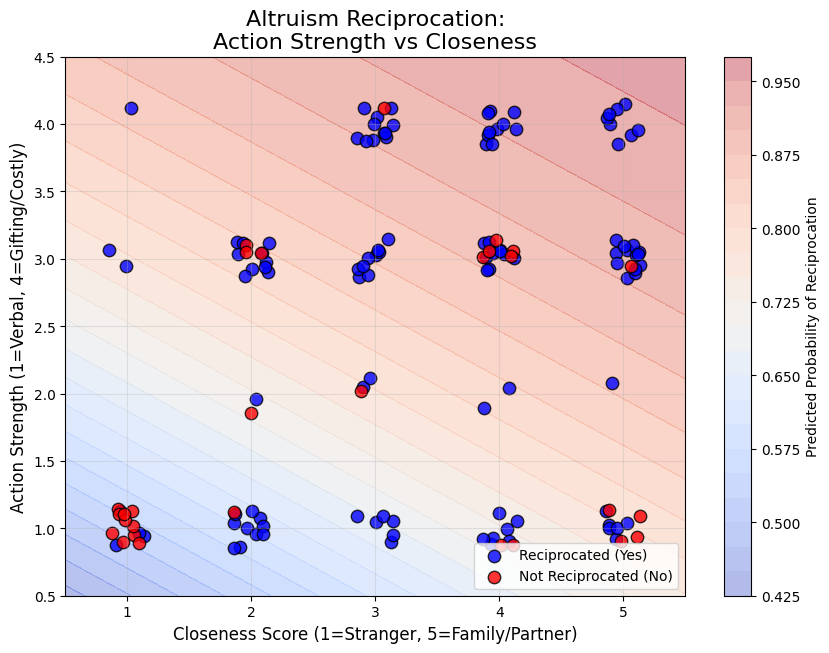

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

contour = plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm', levels=20)
plt.colorbar(contour, label='Predicted Probability of Reciprocation')

np.random.seed(42)
jitter_x = X[:, 0] + np.random.uniform(-0.15, 0.15, size=len(X))
jitter_y = X[:, 1] + np.random.uniform(-0.15, 0.15, size=len(X))

plt.scatter(jitter_x[y == 1], jitter_y[y == 1], c='blue', edgecolors='k',
            label='Reciprocated (Yes)', s=80, alpha=0.8)
plt.scatter(jitter_x[y == 0], jitter_y[y == 0], c='red', edgecolors='k',
            label='Not Reciprocated (No)', s=80, alpha=0.8)

plt.title('Altruism Reciprocation:\nAction Strength vs Closeness', fontsize=16)
plt.xlabel('Closeness Score (1=Stranger, 5=Family/Partner)', fontsize=12)
plt.ylabel('Action Strength (1=Verbal, 4=Gifting/Costly)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
xx_3d, yy_3d = np.meshgrid(np.linspace(x_min, x_max, 50), np.linspace(y_min, y_max, 50))
Z_3d = clf.predict_proba(np.c_[xx_3d.ravel(), yy_3d.ravel()])[:, 1].reshape(xx_3d.shape)

fig = go.Figure()

fig.add_trace(go.Surface(
    x=xx_3d, y=yy_3d, z=Z_3d,
    colorscale='magma', opacity=0.4, # Changed 'coolwarm' to 'bluered'
    name='Model Probability Surface',
    showscale=False
))


fig.add_trace(go.Scatter3d(
    x=jitter_x[y == 1], y=jitter_y[y == 1], z=y[y == 1],
    mode='markers',
    marker=dict(size=6, color='blue', line=dict(width=1, color='lime')),
    name='Reciprocated (Yes)'
))

fig.add_trace(go.Scatter3d(
    x=jitter_x[y == 0], y=jitter_y[y == 0], z=y[y == 0],
    mode='markers',
    marker=dict(size=6, color='red', line=dict(width=1, color='yellow')),
    name='Not Reciprocated (No)'
))

fig.update_layout(
    title='Interactive 3D Altruism Model (Drag to Rotate!)',
    scene=dict(
        xaxis_title='Closeness Score',
        yaxis_title='Action Strength',
        zaxis_title='Reciprocation (1=Yes, 0=No)'
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from sklearn.neighbors import KNeighborsClassifier


closeness_map = {'7 - Stranger': 1, '5 - Casual Acquaintance': 2, '6 - Coworker': 2, '8 - Other': 2, '4 - Friend': 3, '3 - Close Friend': 4, '2 - Family Member': 5, '1 - Spouse / Boyfriend / Girlfriend': 5}
action_strength_map = {'2 - Verbal': 1, '1 - Physical': 2, '5 - Other': 2, '4 - Service': 3, '3 - Gifting': 4}
reciprocated_map = {'1 - Yes': 1, '2 - No': 0}

df = pd.read_csv('Honors.PUT DATA HERE.Winter2026.Altruism - CLASS DATA.csv')
df['Closeness'] = df['Subject Type'].map(closeness_map)
df['Action_Strength'] = df['Unnamed: 2'].map(action_strength_map)
df['Reciprocated_Target'] = df['Was it reciprocated?'].map(reciprocated_map)
clean_df = df.dropna(subset=['Closeness', 'Action_Strength', 'Reciprocated_Target']).copy()

X = clean_df[['Closeness', 'Action_Strength']].values
y = clean_df['Reciprocated_Target'].values

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, y)

print("K-Nearest Neighbors model trained successfully!")

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx_3d, yy_3d = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

Z_3d = knn.predict_proba(np.c_[xx_3d.ravel(), yy_3d.ravel()])[:, 1].reshape(xx_3d.shape)

np.random.seed(42)
jitter_x = X[:, 0] + np.random.uniform(-0.15, 0.15, size=len(X))
jitter_y = X[:, 1] + np.random.uniform(-0.15, 0.15, size=len(X))

fig = go.Figure()

fig.add_trace(go.Surface(x=xx_3d, y=yy_3d, z=Z_3d, colorscale='magma', opacity=0.75, name='KNN Probability Surface', showscale=False))

# Scatter points
fig.add_trace(go.Scatter3d(x=jitter_x[y == 1], y=jitter_y[y == 1], z=y[y == 1], mode='markers', marker=dict(size=6, color='cyan', line=dict(width=1, color='black')), name='Reciprocated'))
fig.add_trace(go.Scatter3d(x=jitter_x[y == 0], y=jitter_y[y == 0], z=y[y == 0], mode='markers', marker=dict(size=6, color='red', line=dict(width=1, color='black')), name='Not Reciprocated'))

fig.update_layout(
    title='K-Nearest Neighbors (KNN) Altruism Model',
    scene=dict(xaxis_title='Closeness Score', yaxis_title='Action Strength', zaxis_title='Reciprocation Probability'),
    width=900, height=700, margin=dict(l=0, r=0, b=0, t=50)
)
fig.show()

K-Nearest Neighbors model trained successfully!
